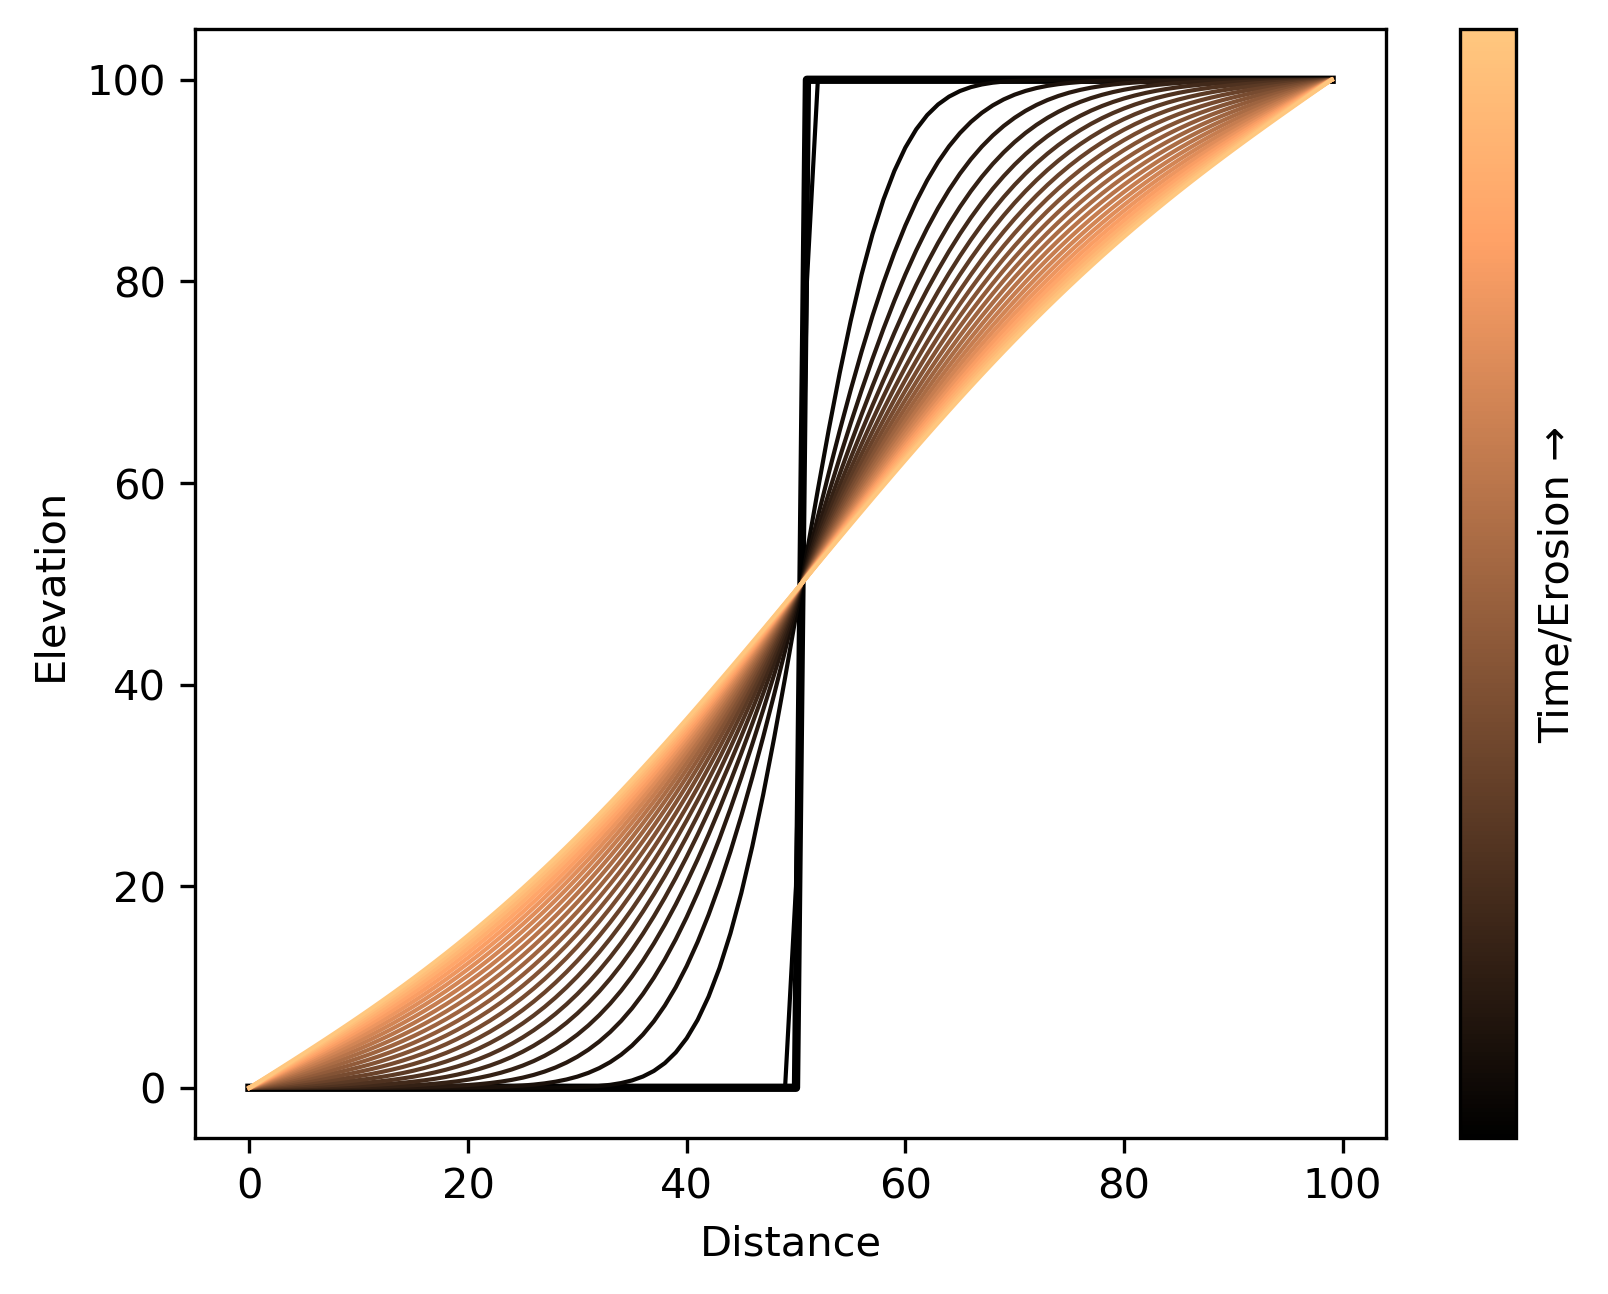

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import copper 
from matplotlib.colors import Normalize

dx = 1
x = np.arange(0, 100, dx, dtype=float)
z = np.zeros(x.shape, dtype=float)
D = 0.01

z[x > 50] += 100

dt = 0.2 * dx * dx / D
total_time = 5*10e3
nts = int(total_time / dt)
z_orig = z.copy()

fig, ax = plt.subplots(dpi=300)
plt.plot(x, z_orig, 'k',lw=2)
colors = copper(np.linspace(0, 1, nts//100))  # Get colors for every 10th iteration
color_idx = 0
n_plots = nts // 100
times = np.linspace(0, total_time, n_plots)
norm = Normalize(vmin=times.min(), vmax=times.max())


for i in range(nts):
    qs = -D * np.diff(z) / dx
    dzdt = -np.diff(qs) / dx
    z[1:-1] += dzdt * dt
    if i % 100 == 0:  
        plt.plot(x, z,lw=1, color=colors[color_idx])
        color_idx += 1
        
sm = plt.cm.ScalarMappable(cmap=copper, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Erosion →')
# Rotate the colorbar label to point upward
cbar.ax.set_ylabel('Time/Erosion →', rotation=90, va='bottom',labelpad=15)
cbar.ax.set_yticks([])

plt.xlabel('Distance')
plt.ylabel('Elevation')
plt.savefig('Figures/diff_cartoon.png')

/var/folders/kg/j5ms0y1x28l_gm2jtsf5j4pr0000gn/T/ipykernel_44911/331872116.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


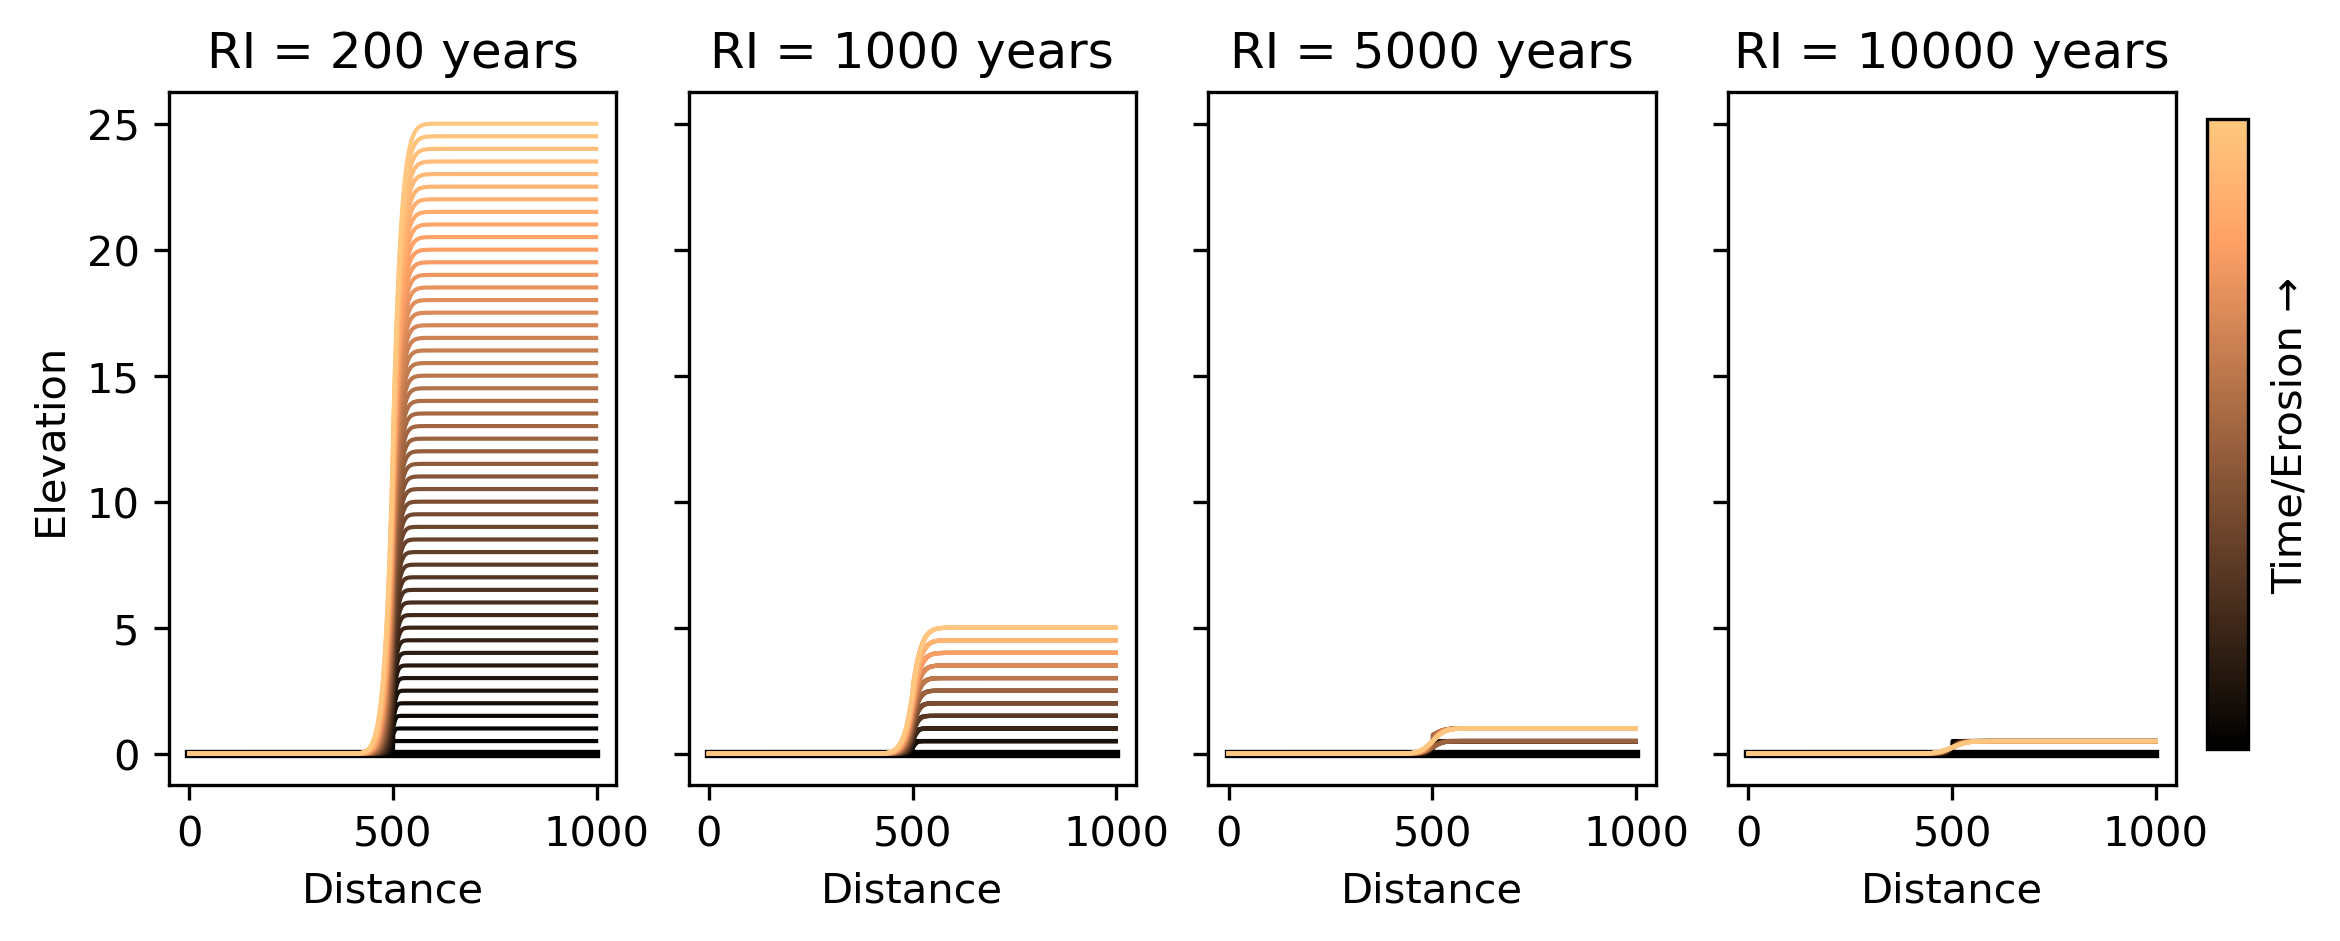

In [28]:
# Parameters
dx = 1
x = np.arange(0, 1000, dx, dtype=float)
D = 0.05  # Diffusion coefficient
dt = 0.2 * dx * dx / D
total_time = 1*10e3
nts = int(total_time / dt)

# Make sure we have at least some plots
plot_interval = max(1, nts // 50)  # Adjust this to control number of plotted lines

# Set a constant slip per event for all scenarios
slip_per_event = 0.5  # meters per event

# Four scenarios with same slip size but different recurrence
scenarios = [
    {"recurrence": 200},     # Frequent events
    {"recurrence": 1000},    # Medium frequency
    {"recurrence": 5000},    # Rare events
    {"recurrence": 10000}    # Very rare events
]

# Create figure with four subplots and space for colorbar
fig = plt.figure(figsize=(9, 3), dpi=300)
gs = plt.GridSpec(1, 5, width_ratios=[1, 1, 1, 1, 0.03], wspace=0.2)

# Create subplots with shared y-axis
axes = []
for i in range(4):
    if i == 0:
        axes.append(plt.subplot(gs[i]))
    else:
        axes.append(plt.subplot(gs[i], sharey=axes[0]))
        plt.setp(axes[-1].get_yticklabels(), visible=False)  # Hide y-ticks for all but first plot

for ax, scenario in zip(axes, scenarios):
    # Initialize profile
    initial_height = 0  # Initial scarp height
    z = np.zeros(x.shape, dtype=float)
    z[x > 500] += initial_height
    z_orig = z.copy()
    
    # Plot initial profile
    ax.plot(x, z_orig, 'k', lw=2)
    
    # Calculate number of plots and get colors
    n_plots = nts // plot_interval
    if n_plots < 1:
        n_plots = 1
    colors = copper(np.linspace(0, 1, n_plots))
    color_idx = 0
    
    # Calculate recurrence steps
    time_per_step = dt
    recurrence_steps = int(scenario["recurrence"] / time_per_step)
    
    # Evolve the profile
    for i in range(nts):
        # Apply diffusion
        qs = -D * np.diff(z) / dx
        dzdt = -np.diff(qs) / dx
        z[1:-1] += dzdt * dt
        
        # Apply fault slip as discrete events of same size
        if i % recurrence_steps == 0:  # Time for an event
            z[x > 500] += slip_per_event
        
        # Plot at regular intervals
        if i % plot_interval == 0 and color_idx < len(colors):
            ax.plot(x, z, lw=1, color=colors[color_idx])
            color_idx += 1
    
    # Set labels
    ax.set_xlabel('Distance')
    if ax == axes[0]:  # Only add y-label to first subplot
        ax.set_ylabel('Elevation')
    ax.set_title(f"RI = {scenario['recurrence']} years")

# Add single colorbar on the right
cbar_ax = fig.add_axes([0.88, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap=copper)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cbar_ax,)
cbar.ax.set_ylabel('Time/Erosion →', rotation=90, va='bottom', labelpad=15)
cbar.ax.set_yticks([])

plt.tight_layout()
plt.savefig('Figures/slip_rate_comparison_equal_events.png',bbox_inches='tight')

/var/folders/kg/j5ms0y1x28l_gm2jtsf5j4pr0000gn/T/ipykernel_44911/936619930.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


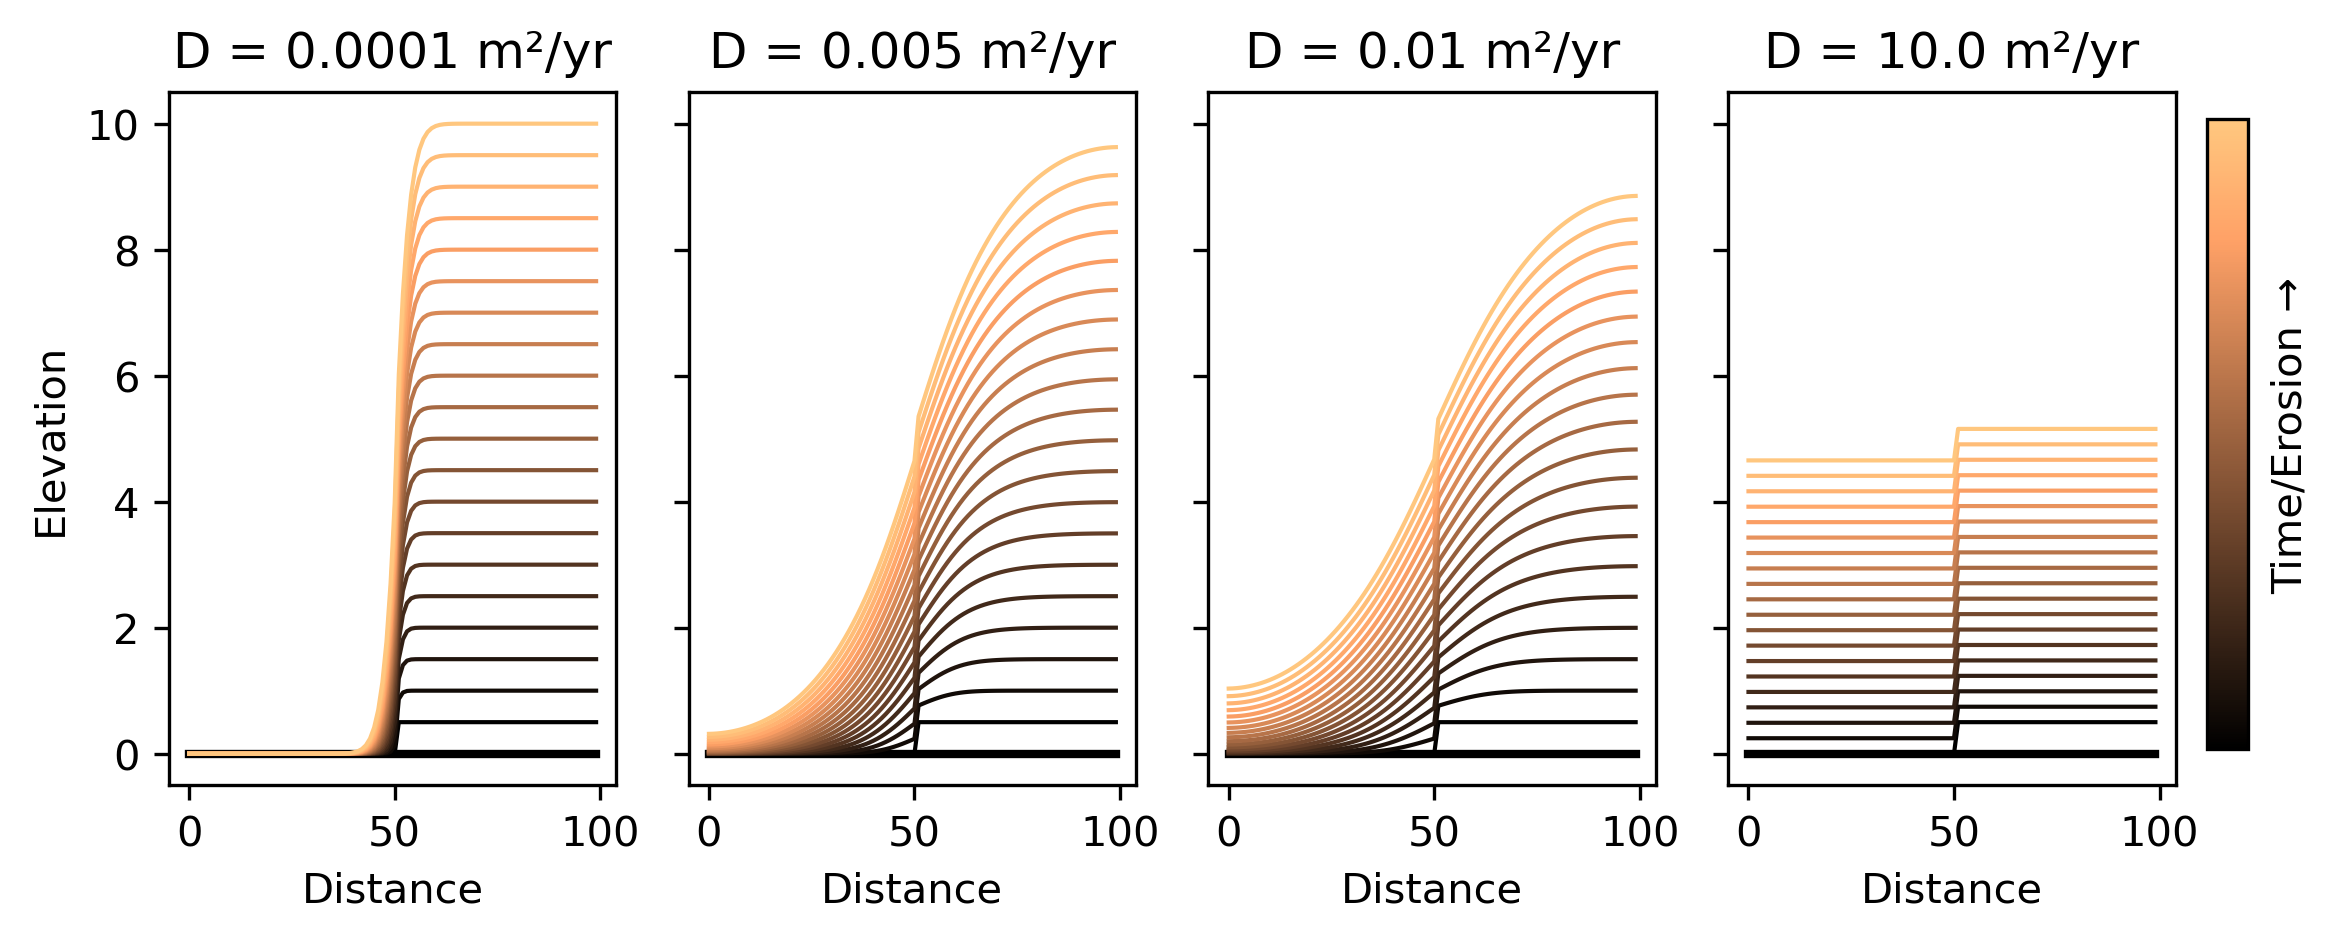

In [24]:
# Parameters
dx = 1
x = np.arange(0, 100, dx, dtype=float)
total_time = 1*10e4
slip_per_event = 0.5  # meters per event
recurrence = 5000     # years between events

# Four scenarios with different diffusion coefficients
scenarios = [
    {"D": 0.0001},    # Very low diffusion
    {"D": 0.005},    # Low diffusion
    {"D": 0.01},     # Medium diffusion
    {"D": 10.0}     # Very high diffusion
]

# Create figure with four subplots and space for colorbar
fig = plt.figure(figsize=(9, 3), dpi=300)
gs = plt.GridSpec(1, 5, width_ratios=[1, 1, 1, 1, 0.03], wspace=0.2)

# Create subplots with shared y-axis
axes = []
for i in range(4):
    if i == 0:
        axes.append(plt.subplot(gs[i]))
    else:
        axes.append(plt.subplot(gs[i], sharey=axes[0]))
        plt.setp(axes[-1].get_yticklabels(), visible=False)

for ax, scenario in zip(axes, scenarios):
    # Initialize profile
    initial_height = 0  # Initial scarp height
    z = np.zeros(x.shape, dtype=float)
    z[x > 50] += initial_height
    z_orig = z.copy()
    
    # Calculate stable time step
    dt = min(1.0, 0.2 * dx * dx / scenario["D"])
    nts = int(total_time / dt)
    
    # Plot initial profile
    ax.plot(x, z_orig, 'k', lw=2)
    
    # Calculate number of plots and get colors
    plot_interval = max(1, nts // 20)
    n_plots = nts // plot_interval
    colors = copper(np.linspace(0, 1, n_plots))
    color_idx = 0
    
    # Calculate recurrence steps
    recurrence_steps = max(1, int(recurrence / dt))
    
    # Evolve the profile
    for i in range(nts):
        # Apply diffusion with zero-flux boundary conditions
        # Calculate fluxes
        dz = np.diff(z)
        qs = -scenario["D"] * dz / dx
        
        # Set boundary fluxes to zero
        qs = np.concatenate(([0], qs, [0]))
        
        # Update elevations using flux differences
        dzdt = -np.diff(qs) / dx
        z += dzdt * dt
        
        # Apply fault slip as discrete events
        if i % recurrence_steps == 0:
            z[x > 50] += slip_per_event
        
        # Plot at regular intervals
        if i % plot_interval == 0 and color_idx < len(colors):
            ax.plot(x, z, lw=1, color=colors[color_idx])
            color_idx += 1
    
    # Set labels
    ax.set_xlabel('Distance')
    if ax == axes[0]:
        ax.set_ylabel('Elevation')
    ax.set_title(f"D = {scenario['D']} m²/yr")

# Add single colorbar on the right
cbar_ax = fig.add_axes([0.88, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap=copper)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.ax.set_ylabel('Time/Erosion →', rotation=90, va='bottom', labelpad=15)
cbar.ax.set_yticks([])

plt.tight_layout()